In [171]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
import pickle
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

ia.seed(1)

In [13]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.2),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-10, 10),
        shear=(-4, 4)
    )
], random_order=True) # apply augmenters in random order

In [14]:
path ="samples"
typ = 'train'

imgs = os.listdir(path)
labels = [f.strip('.jpg') for f in imgs]

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

In [141]:
N = 1000
dim = 227

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}/{label}'):
        os.mkdir(f'{typ}/{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}/{label}/{label}_{i}.jpg',images_aug[i])

In [154]:
path ="samples"
typ = 'test'

imgs = os.listdir(path)
labels = [f.strip('.jpg') for f in imgs]

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

In [155]:
N = 1000
dim = 227

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}/{label}'):
        os.mkdir(f'{typ}/{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}/{label}/{label}_{i}.jpg',images_aug[i])

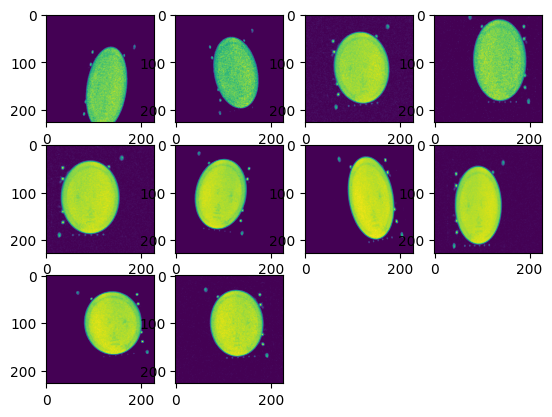

In [142]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

In [69]:
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

{0: '24. Google Nest Hub Max_H2A',
 1: '25. Google Stadia Game Controller_H2B',
 2: '09. Google Nest Cam IQ Outdoor_KT1UM9',
 3: '08. Google Chromecast Black_NC2-6A5 BLACK',
 4: '26. Google Door Camera_ATLRQ1US',
 5: '12. Google TV Remote_G9N9N',
 6: '19. Google Nest Doorbell (Battery)_GWX3T',
 7: '03. Chromecast Ultra (2016)_G2RNL',
 8: '27. Google Nest Learning Thermostat (White)_AK2L2R',
 9: '10. Google Nest Wifi Router_G6ZUC',
 10: '15. Google Home_Home',
 11: '18. Google Nest Wifi Pro_SNOW',
 12: '02. Google Nest Hello Doorbell_A0077',
 13: '05. Google Nest Cam Outdoor_G3AL9',
 14: '21. Google Nest Power Connector_GVNZ4',
 15: 'Google Nest Audio',
 16: '14. Google Nest Protect smoke alarm_NST-4895',
 17: '22. Google Nest Temperature Sensor White_T5000SF',
 18: '06. Google Nest Cam IQ Indoor_G9Q9T',
 19: '01. Google Nest Learning Thermostat (Black)_H1HB1J',
 20: '04. Google Wifi (1 pk)_H2D',
 21: '20. Google Nest Wifi Point_H2E-Google',
 22: '11. Google Home Mini_H2C',
 23: '17. Go

In [145]:
X = []
y = [] #number
path="train"
IMG_SIZE=100
for k,label in enumerate(labels):
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i),0)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        X.append(img)
        y.append(k)

In [146]:
# shuffle
X,y = shuffle(X,y)

In [147]:
X = np.array(X).reshape(len(X),-1)
# norm
X = X/255.0
y = np.array(y)

In [148]:
print(X.shape)
print(y.shape)

(26000, 10000)
(26000,)


In [149]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [150]:
svc = SVC(kernel='linear',gamma='auto')
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [156]:
y2 = svc.predict(X_val)

In [157]:
# calc accuracy
print("Accuracy on unknown data is",accuracy_score(y_val,y2))

Accuracy on unknown data is 0.948


In [158]:
print("Accuracy on unknown data is")
print(classification_report(y_val,y2))

Accuracy on unknown data is
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       241
           1       1.00      1.00      1.00       234
           2       0.97      0.97      0.97       241
           3       0.98      0.98      0.98       241
           4       0.99      1.00      0.99       236
           5       0.98      0.97      0.98       265
           6       0.99      0.98      0.99       255
           7       0.79      0.92      0.85       260
           8       0.94      0.94      0.94       254
           9       0.98      1.00      0.99       243
          10       0.97      0.96      0.97       236
          11       0.97      0.97      0.97       248
          12       0.98      0.95      0.97       273
          13       0.96      0.98      0.97       265
          14       0.95      0.92      0.93       239
          15       0.89      0.95      0.92       263
          16       1.00      1.00      1.00       266

In [159]:
# save the model to disk
filename = 'obj_cla_1000_gray.sav'
pickle.dump(svc, open(filename, 'wb'))

Even when flatten length of new income data does not equal, model still work

Text(0.5, 1.0, 'pred: 14. Google Nest Protect smoke alarm_NST-4895\n(14. Google Nest Protect smoke alarm_NST-4895)')

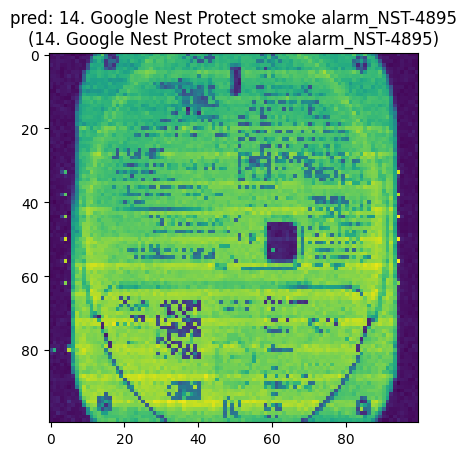

In [164]:
# random test
path = 'samples'
imgs = os.listdir(path)
i = random.choice(imgs)
img = cv2.imread(os.path.join(path,i),0)
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
y= svc.predict(img)
plt.title("pred: " + i.strip('.jpg') +"\n(" + dic[int(y)] + ")")

In [182]:
# batch test
path = 'test'
preds = []
ground_truth = []
labels = os.listdir(path)

for label in labels:
    imgs = os.listdir(os.path.join(path,label))
    print("testing label: ",label)
    for i in tqdm(imgs):
        i = os.path.join(path,label,i)
        img = cv2.imread(i,0)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0
        img = img.reshape(1,-1)
        preds.append(dic[int(svc.predict(img))]) # collect pred
        ground_truth.append(label) # collect ground truth

testing label:  Google Nest Audio


100%|███████████████████████████████████████| 1000/1000 [00:40<00:00, 24.95it/s]


testing label:  22. Google Nest Temperature Sensor White_T5000SF


100%|███████████████████████████████████████| 1000/1000 [00:41<00:00, 24.08it/s]


testing label:  27. Google Nest Learning Thermostat (White)_AK2L2R


...

100%|███████████████████████████████████████| 1000/1000 [00:38<00:00, 26.26it/s]


testing label:  24. Google Nest Hub Max_H2A


100%|███████████████████████████████████████| 1000/1000 [00:37<00:00, 26.64it/s]


testing label:  19. Google Nest Doorbell (Battery)_GWX3T


100%|███████████████████████████████████████| 1000/1000 [00:38<00:00, 26.25it/s]


In [189]:
# calc accuracy
count = 0
for i in range(len(ground_truth)):
    if ground_truth[i] == preds[i]:
        count+=1

print("Accuracy valid on ",accuracy_score(ground_truth,preds))

Accuracy valid on  0.936076923076923


In [190]:
path = "samples"
imgs = os.listdir(path)
for i in imgs:
    img = cv2.imread(os.path.join(path,i),0)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0
    img = img.reshape(1,-1)
    y= svc.predict(img)
    pred = dic[int(y)]
    print(i,"pred: ",i.strip('.jpg') == pred)

24. Google Nest Hub Max_H2A.jpg pred:  True
25. Google Stadia Game Controller_H2B.jpg pred:  True
09. Google Nest Cam IQ Outdoor_KT1UM9.jpg pred:  True
08. Google Chromecast Black_NC2-6A5 BLACK.jpg pred:  True
26. Google Door Camera_ATLRQ1US.jpg pred:  True
12. Google TV Remote_G9N9N.jpg pred:  True
19. Google Nest Doorbell (Battery)_GWX3T.jpg pred:  True
03. Chromecast Ultra (2016)_G2RNL.jpg pred:  True
27. Google Nest Learning Thermostat (White)_AK2L2R.jpg pred:  True
10. Google Nest Wifi Router_G6ZUC.jpg pred:  True
15. Google Home_Home.jpg pred:  True
18. Google Nest Wifi Pro_SNOW.jpg pred:  True
02. Google Nest Hello Doorbell_A0077.jpg pred:  True
05. Google Nest Cam Outdoor_G3AL9.jpg pred:  True
21. Google Nest Power Connector_GVNZ4.jpg pred:  True
Google Nest Audio.jpg pred:  True
14. Google Nest Protect smoke alarm_NST-4895.jpg pred:  True
22. Google Nest Temperature Sensor White_T5000SF.jpg pred:  True
06. Google Nest Cam IQ Indoor_G9Q9T.jpg pred:  True
01. Google Nest Learnin